<a href="https://colab.research.google.com/github/santed7/Data-Science-Cohort-20/blob/main/Capstone_OrgTrustQt_Project_OTQ_Working_Copy_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Organizational Trust Quotient (OTQ) — Communication Stream Regression
### Capstone Project | CNM Data Science Bootcamp
**Author:** Dr. Vernon T. Cox, SanTed Quantum Scheduling (SQS)

---

## Project Overview

The **Organizational Trust Quotient (OTQ)** is a data-driven framework for passively measuring trust in organizational communication. Rather than asking employees to fill out surveys, the OTQ analyzes communication *metadata* — message frequency, response times, meeting participation, and channel engagement — to produce an objective, numeric measure of organizational trust.

### The Business Problem
Organizations lose significant productivity and revenue due to low trust: delayed decisions, siloed teams, high turnover, and slow response to problems. Traditional trust assessments are infrequent, subjective, and disruptive. The OTQ offers a **minimal-disruption, continuous monitoring alternative** grounded in communication science.

### This Notebook Does the Following
1. Ingests communication exports from Slack, Microsoft Teams, and Outlook Calendar
2. Standardizes them into a single event table
3. Calculates an OTQ Engagement Score (**Event Units / EU**) for each communication event
4. Aggregates features by day and engineers log-transformed predictors
5. Creates a proxy outcome variable (median response time in minutes) from chat sequences
6. Trains a Ridge regression model to predict the outcome from engagement features
7. Performs full EDA and produces inline visualizations
8. Reports model diagnostics (R², MAE, coefficients)

### Data Sources
| Source | Format | Key Fields |
|--------|--------|-----------|
| Slack | JSON export or CSV | timestamp, user, channel, text |
| Microsoft Teams | CSV log extract | timestamp, participants, duration, type |
| Outlook Calendar | CSV export | subject, start, end, organizer, attendees |

## Step 1: Imports & Setup

We import all required libraries here. `%matplotlib inline` ensures all plots render directly inside this notebook rather than being saved only to disk.

In [ ]:
%matplotlib inline

from __future__ import annotations

import argparse
import json
import math
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Helper Functions

These are utility functions used throughout the notebook. They handle type conversion and timestamp parsing safely — avoiding crashes when the data is messy or missing.

In [ ]:
def safe_int(x, default=0) -> int:
    try:
        return int(x)
    except Exception:
        return default

def safe_float(x, default=0.0) -> float:
    try:
        return float(x)
    except Exception:
        return default

def parse_datetime(value: Any) -> Optional[pd.Timestamp]:
    """Parse a timestamp value into a UTC-aware pandas Timestamp."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None
    if isinstance(value, pd.Timestamp):
        ts = value
    else:
        s = str(value).strip()
        if re.fullmatch(r"\d{10}(\.\d+)?", s):
            return pd.to_datetime(float(s), unit="s", utc=True)
        ts = pd.to_datetime(s, utc=True, errors="coerce")
    if ts is pd.NaT:
        return None
    if ts.tzinfo is None:
        ts = ts.tz_localize(timezone.utc)
    else:
        ts = ts.tz_convert(timezone.utc)
    return ts

def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)

print("Helper functions defined.")

Helper functions defined.


## Step 3: OTQ Event Unit (EU) Scoring Formula

Each communication event is converted into a single numeric **Event Unit (EU)** score. The formula has three components:

- **Base score** — Different event types carry different trust signals. A meeting has higher base weight than a quick chat message, because it implies a greater commitment of time and attention.
- **Duration bonus** — Longer interactions (up to 2 hours) add a small increment. This is capped to avoid outliers dominating the score.
- **Participant bonus** — More participants increase the score, but with **diminishing returns** (logarithmic scaling). A 10-person all-hands adds less incremental trust signal per participant than a focused 2-person conversation.

| Event Type | Base EU |
|-----------|---------|
| Meeting / Teams Meeting | 24.5 |
| Chat / Slack Message | 9.5 |
| Phone / Call | 8.5 |
| Email / Outlook | 6.0 |
| Other | 5.0 |

These weights can be tuned to match an organization's specific OTQ policy.

In [ ]:
def otq_event_units(event_type: str, duration_min: float, participant_count: int) -> float:
    """
    Converts a single communication event into a numeric OTQ Event Unit (EU) score.

    Parameters
    ----------
    event_type      : string label (e.g. 'meeting', 'chat', 'email')
    duration_min    : duration in minutes (0 if unknown)
    participant_count: number of people involved (>= 1)

    Returns
    -------
    EU score (float)
    """
    t = (event_type or "").lower()

    if "meeting" in t or "teams_meeting" in t:
        base = 24.5
    elif "call" in t or "phone" in t:
        base = 8.5
    elif "email" in t or "outlook" in t:
        base = 6.0
    elif "chat" in t or "message" in t or "slack" in t:
        base = 9.5
    else:
        base = 5.0

    dur_bonus = min(max(duration_min, 0.0), 120.0) / 60.0        # 0 to 2
    pc = max(participant_count, 1)
    participant_bonus = math.log(pc, 2) * 1.5                     # log scale

    return float(base + dur_bonus + participant_bonus)

print("EU scoring function defined.")

EU scoring function defined.


## Step 4: Data Parsers (Input Ingestion)

These functions read communication export files and normalize them into a **common schema**. Each source (Slack, Outlook, Teams) has its own export format, so the parsers translate each one into the same columns:

`source | event_type | timestamp | actor | channel | text | duration_min | participant_count`

This normalization step is what allows us to combine all data sources for analysis.

In [ ]:
def load_csv_any(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, dtype=str, keep_default_na=False)

def load_json_any(path: Path) -> Any:
    text = path.read_text(encoding="utf-8", errors="ignore").strip()
    if not text:
        return []
    if text.lstrip().startswith("{") or text.lstrip().startswith("["):
        return json.loads(text)
    rows = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

def parse_slack_file(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        df = load_csv_any(path)
        ts_col  = next((c for c in df.columns if c.lower() in ["ts","timestamp","time","date"]), None)
        text_col = next((c for c in df.columns if c.lower() in ["text","message","body"]), None)
        user_col = next((c for c in df.columns if c.lower() in ["user","username","from"]), None)
        chan_col = next((c for c in df.columns if c.lower() in ["channel","room","thread"]), None)
        return pd.DataFrame({
            "source": "slack", "event_type": "chat",
            "timestamp": df[ts_col] if ts_col else None,
            "actor": df[user_col] if user_col else None,
            "channel": df[chan_col] if chan_col else None,
            "text": df[text_col] if text_col else None,
            "duration_min": 0.0, "participant_count": 2,
        })
    data = load_json_any(path)
    if isinstance(data, dict): data = [data]
    rows = []
    for obj in data:
        if not isinstance(obj, dict): continue
        rows.append({
            "source": "slack", "event_type": "chat",
            "timestamp": obj.get("ts") or obj.get("timestamp") or obj.get("time"),
            "actor": obj.get("user") or obj.get("username"),
            "channel": obj.get("channel") or obj.get("room"),
            "text": obj.get("text") or obj.get("message"),
            "duration_min": 0.0, "participant_count": 2,
        })
    return pd.DataFrame(rows)

def parse_outlook_calendar_file(path: Path) -> pd.DataFrame:
    df = load_csv_any(path)
    cols = {c.lower(): c for c in df.columns}
    subj  = df[cols["subject"]] if "subject" in cols else ""
    start = df[cols.get("start", cols.get("start time",""))] if ("start" in cols or "start time" in cols) else ""
    end   = df[cols.get("end",   cols.get("end time",""))]   if ("end"   in cols or "end time"   in cols) else ""
    org   = df[cols["organizer"]] if "organizer" in cols else ""
    req   = df[cols["required attendees"]] if "required attendees" in cols else ""
    opt   = df[cols["optional attendees"]] if "optional attendees" in cols else ""
    def count_people(s_req, s_opt):
        def sp(s):
            s = (s or "").strip()
            return [p.strip() for p in re.split(r"[;,]", s) if p.strip()] if s else []
        return max(1, len(set(sp(s_req)+sp(s_opt)))+1)
    part_counts = [count_people(r,o) for r,o in zip(req.tolist(), opt.tolist())]
    return pd.DataFrame({
        "source": "outlook", "event_type": "meeting",
        "timestamp": start, "actor": org, "channel": "calendar", "text": subj,
        "duration_min": np.nan, "participant_count": part_counts,
    })

def parse_teams_file(path: Path) -> pd.DataFrame:
    df = load_csv_any(path)
    cols = {c.lower(): c for c in df.columns}
    ts_col   = next((cols[k] for k in cols if k in ["timestamp","time","date","start","start time","start_time"]), None)
    subj_col = next((cols[k] for k in cols if k in ["subject","title","meeting subject","name"]), None)
    org_col  = next((cols[k] for k in cols if k in ["organizer","from","owner"]), None)
    dur_col  = next((cols[k] for k in cols if k in ["duration","duration_min","minutes"]), None)
    part_col = next((cols[k] for k in cols if k in ["participants","attendees","participant_count"]), None)
    type_col = next((cols[k] for k in cols if k in ["type","interactiontype","event_type"]), None)
    return pd.DataFrame({
        "source": "teams",
        "event_type": df[type_col] if type_col else "teams_meeting",
        "timestamp": df[ts_col] if ts_col else None,
        "actor": df[org_col] if org_col else None,
        "channel": "teams",
        "text": df[subj_col] if subj_col else None,
        "duration_min": df[dur_col] if dur_col else 0.0,
        "participant_count": df[part_col] if part_col else 2,
    })

def discover_inputs(input_dir: Path) -> List[Path]:
    return [p for p in input_dir.rglob("*") if p.is_file() and p.suffix.lower() in {".csv",".json",".jsonl"}]

def parse_any(path: Path) -> Optional[pd.DataFrame]:
    name = path.name.lower()
    try:
        if "slack" in name:     return parse_slack_file(path)
        if "outlook" in name or "calendar" in name:
            if path.suffix.lower() == ".csv": return parse_outlook_calendar_file(path)
            return None
        if "teams" in name:
            if path.suffix.lower() == ".csv": return parse_teams_file(path)
            return None
        if path.suffix.lower() == ".csv":     return parse_teams_file(path)
        return None
    except Exception as e:
        print(f"[WARN] Failed parsing {path}: {e}")
        return None

print("Parsers defined.")

Parsers defined.


## Step 5: Feature Engineering & Outcome Construction

### Data Cleaning Notes
The `build_event_table()` function performs the following cleaning steps:
- **Timestamp normalization**: All timestamps are parsed to UTC-aware format; rows with unparseable timestamps are dropped.
- **Type coercion**: `duration_min` and `participant_count` are safely cast to numeric types; invalid values default to 0.
- **EU scoring**: Applied row-by-row using the formula defined above.
- **Text length**: Character count is computed as a crude proxy for message content volume.

### Outcome Variable (Proxy)
Since live organizational KPI data (e.g., schedule variance, ticket resolution time) is not yet available for this proof-of-concept, we construct a **proxy outcome**: the **median response time in minutes** between consecutive messages within the same communication channel.

A lower response time indicates more fluid, responsive communication — a signal consistent with higher organizational trust. This proxy will be replaced with real KPIs in the full deployment.

### Feature Engineering
Raw daily totals are **log-transformed** (`np.log1p`) before regression. This is standard practice when count-based features are right-skewed — it compresses large values and stabilizes variance, which improves regression performance.

In [ ]:
def build_event_table(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    df = pd.concat(dfs, ignore_index=True)
    df["ts"] = df["timestamp"].apply(parse_datetime)
    df = df.dropna(subset=["ts"]).copy()
    df["date"] = df["ts"].dt.floor("D")
    df["duration_min"]    = df["duration_min"].apply(safe_float)
    df["participant_count"] = df["participant_count"].apply(safe_int)
    df["eu"] = [
        otq_event_units(t, d, p)
        for t, d, p in zip(df["event_type"].astype(str), df["duration_min"], df["participant_count"])
    ]
    df["text_len"] = df["text"].fillna("").astype(str).str.len()
    return df

def make_daily_features(events: pd.DataFrame) -> pd.DataFrame:
    g = events.groupby("date", as_index=False).agg(
        total_events    = ("eu", "size"),
        total_eu        = ("eu", "sum"),
        avg_eu          = ("eu", "mean"),
        avg_participants= ("participant_count", "mean"),
        total_text      = ("text_len", "sum"),
        avg_duration    = ("duration_min", "mean"),
    )
    g["log_total_eu"]     = np.log1p(g["total_eu"])
    g["log_total_events"] = np.log1p(g["total_events"])
    g["log_total_text"]   = np.log1p(g["total_text"].clip(lower=0))
    return g

def compute_outcome_proxy(events: pd.DataFrame) -> pd.DataFrame:
    """
    Proxy outcome: median minutes between consecutive messages in the same channel.
    A lower value = more responsive communication = higher trust signal.
    Replace with a real KPI (ticket close rate, schedule variance, etc.) for production.
    """
    e = events.sort_values("ts").copy()
    e["channel_key"] = e["source"].astype(str) + "::" + e["channel"].astype(str)
    e["prev_ts"]     = e.groupby("channel_key")["ts"].shift(1)
    e["delta_min"]   = (e["ts"] - e["prev_ts"]).dt.total_seconds() / 60.0
    e = e[(e["delta_min"].notna()) & (e["delta_min"] > 0) & (e["delta_min"] <= 720)].copy()
    rt = e.groupby("date", as_index=False).agg(
        median_response_min = ("delta_min", "median"),
        p90_response_min    = ("delta_min", lambda s: np.percentile(s, 90)),
        samples             = ("delta_min", "size"),
    )
    return rt

print("Feature engineering & outcome functions defined.")

Feature engineering & outcome functions defined.


## Step 6: Real Data Input — Apostles Communication Database

This notebook loads **three CSV files** containing the **Apostles Communication Database** — a KJV Bible-sourced test dataset structured to match the OTQ pipeline's expected schema.

### How to load the files (choose ONE method below)

| Method | Best for |
|--------|----------|
| **Method A — Colab upload widget** | Running in Google Colab |
| **Method B — Google Drive mount** | Files already in your Google Drive |
| **Method C — Local path** | Running Jupyter locally on your own machine |

The code cell below auto-detects whether you are in Colab and offers the right method. **If you are in Colab, it will show a file picker — select all three CSV files at once.**

| File | Parser | Events |
|------|--------|--------|
| `slack_apostles.csv` | `parse_slack_file()` | 56 chat messages (KJV Epistles & Acts) |
| `teams_apostles.csv` | `parse_teams_file()` | 30 meetings (councils, journeys) |
| `outlook_apostles.csv` | `parse_outlook_calendar_file()` | 20 calendar assemblies |


In [ ]:
from pathlib import Path
import os, sys

# ═════════════════════════════════════════════════════════════════════════════
# STEP 6A — Detect environment and load apostles CSV files
# ═════════════════════════════════════════════════════════════════════════════

IN_COLAB = "google.colab" in sys.modules
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

EXPECTED_FILES = ["slack_apostles.csv", "teams_apostles.csv", "outlook_apostles.csv"]
file_store = {}   # will hold {filename: Path} for all three files

# ─────────────────────────────────────────────────────────────────────────────
# METHOD A — Google Colab file upload widget
# ─────────────────────────────────────────────────────────────────────────────
if IN_COLAB:
    print("Google Colab detected.")
    print("A file picker will appear below.")
    print("Please select all three files:")
    for f in EXPECTED_FILES:
        print(f"   • {f}")
    print()

    from google.colab import files
    uploaded = files.upload()   # shows the file picker

    # Save uploaded bytes to /tmp so parsers can read them as Paths
    for fname, data in uploaded.items():
        dest = Path("/tmp") / fname
        dest.write_bytes(data)
        file_store[fname] = dest
        print(f"  ✓  {fname}  ({len(data)/1024:.1f} KB)  → saved to {dest}")

# ─────────────────────────────────────────────────────────────────────────────
# METHOD B — Google Drive mount (uncomment if files are in Drive)
# ─────────────────────────────────────────────────────────────────────────────
# from google.colab import drive
# drive.mount("/content/drive")
# DRIVE_DATA = Path("/content/drive/MyDrive/DataSci_Projects/LongTerm Projects/OrgTrustQuotient/OTQCode/data")
# for fname in EXPECTED_FILES:
#     p = DRIVE_DATA / fname
#     if p.exists():
#         file_store[fname] = p

# ─────────────────────────────────────────────────────────────────────────────
# METHOD C — Local Jupyter (searches common paths automatically)
# ─────────────────────────────────────────────────────────────────────────────
if not IN_COLAB:
    LOCAL_CANDIDATES = [
        Path("./data"),
        Path("G:/My Drive/DataSci_Projects/LongTerm Projects/OrgTrustQuotient/OTQCode/data"),
        Path("H:/My Drive/DataSci_Projects/LongTerm Projects/OrgTrustQuotient/OTQCode/data"),
        Path.home() / "My Drive/DataSci_Projects/LongTerm Projects/OrgTrustQuotient/OTQCode/data",
    ]
    for candidate in LOCAL_CANDIDATES:
        if candidate.exists():
            for fname in EXPECTED_FILES:
                fpath = candidate / fname
                if fpath.exists():
                    file_store[fname] = fpath
        if len(file_store) == 3:
            print(f"✓  All files found in: {candidate.resolve()}")
            break

    if len(file_store) < 3:
        missing = [f for f in EXPECTED_FILES if f not in file_store]
        print("❌  Could not auto-locate these files:")
        for f in missing:
            print(f"   • {f}")
        print()
        print("Options:")
        print("  1. Copy the CSV files into a 'data' subfolder next to this notebook.")
        print("  2. Add your folder path to LOCAL_CANDIDATES in the cell above.")
        raise FileNotFoundError(f"Missing: {missing}")

# ─────────────────────────────────────────────────────────────────────────────
# Confirm all three files are ready, then parse
# ─────────────────────────────────────────────────────────────────────────────
missing = [f for f in EXPECTED_FILES if f not in file_store]
if missing:
    raise FileNotFoundError(
        f"Still missing after upload: {missing}\n"
        "Make sure you selected all three CSV files in the picker."
    )

print()
print("=" * 60)
print("OTQ DATA INPUT — Apostles Communication Database")
print("=" * 60)
for fname in EXPECTED_FILES:
    p = file_store[fname]
    rows = sum(1 for _ in open(p)) - 1
    print(f"  ✓  {fname:<30}  {rows:>3} rows")
print()

# ── Parse each file through its OTQ parser ───────────────────────────────────
df_slack   = parse_slack_file(file_store["slack_apostles.csv"])
df_teams   = parse_teams_file(file_store["teams_apostles.csv"])
df_outlook = parse_outlook_calendar_file(file_store["outlook_apostles.csv"])

parsed_frames = [df_slack, df_teams, df_outlook]

print(f"Slack  parser  → {len(df_slack):>3} events loaded")
print(f"Teams  parser  → {len(df_teams):>3} events loaded")
print(f"Outlook parser → {len(df_outlook):>3} events loaded")
print(f"                {'─'*20}")
print(f"Total raw events: {sum(len(d) for d in parsed_frames)}")
print()
print("── Slack sample (first 3 rows) " + "─" * 28)
display(df_slack.head(3))
print()
print("── Teams sample (first 3 rows) " + "─" * 28)
display(df_teams.head(3))
print()
print("── Outlook sample (first 3 rows) " + "─" * 26)
display(df_outlook.head(3))


Google Colab detected.
A file picker will appear below.
Please select all three files:
   • slack_apostles.csv
   • teams_apostles.csv
   • outlook_apostles.csv



Saving outlook_apostles.csv to outlook_apostles.csv
Saving slack_apostles.csv to slack_apostles.csv
Saving teams_apostles.csv to teams_apostles.csv
  ✓  outlook_apostles.csv  (2.9 KB)  → saved to /tmp/outlook_apostles.csv
  ✓  slack_apostles.csv  (6.7 KB)  → saved to /tmp/slack_apostles.csv
  ✓  teams_apostles.csv  (2.6 KB)  → saved to /tmp/teams_apostles.csv

OTQ DATA INPUT — Apostles Communication Database
  ✓  slack_apostles.csv               56 rows
  ✓  teams_apostles.csv               30 rows
  ✓  outlook_apostles.csv             20 rows

Slack  parser  →  56 events loaded
Teams  parser  →  30 events loaded
Outlook parser →  20 events loaded
                ────────────────────
Total raw events: 106

── Slack sample (first 3 rows) ────────────────────────────


,source,event_type,timestamp,actor,channel,text,duration_min,participant_count
0,slack,chat,2025-06-15 09:00:00,Peter,#jerusalem,"Repent, and be baptized every one of you in th...",0.0,2
1,slack,chat,2025-06-15 09:12:00,John,#jerusalem,That which we have seen and heard declare we u...,0.0,2
2,slack,chat,2025-06-15 09:25:00,Andrew,#jerusalem,"He first findeth his own brother Simon, and sa...",0.0,2



── Teams sample (first 3 rows) ────────────────────────────


,source,event_type,timestamp,actor,channel,text,duration_min,participant_count
0,teams,teams_meeting,2025-06-15 08:00:00,Peter,teams,Pentecost Gathering — Jerusalem Upper Room,120,120
1,teams,teams_meeting,2025-06-22 09:00:00,Paul,teams,First Missionary Journey Debrief — Antioch,90,5
2,teams,teams_meeting,2025-06-29 10:00:00,Peter,teams,Healing at Beautiful Gate — Review,45,3



── Outlook sample (first 3 rows) ──────────────────────────


,source,event_type,timestamp,actor,channel,text,duration_min,participant_count
0,outlook,meeting,2025-06-15 09:00:00,Peter,calendar,Pentecost — Day of the Holy Spirit,NaN,13
1,outlook,meeting,2025-07-10 09:00:00,James_Alphaeus,calendar,Jerusalem Council on Gentile Circumcision,NaN,13
2,outlook,meeting,2025-06-22 08:00:00,Paul,calendar,First Missionary Journey — Departure Blessing,NaN,6


## Step 7: Build Unified Event Table & Daily Features

Here we merge all three parsed data sources into a single event table, apply the EU scoring formula, and aggregate to daily-level features for modeling.

A key output is the **Apostle Participation Summary** — a per-actor breakdown showing total EU score, event count, and number of unique channels engaged. This is the OTQ equivalent of an individual trust-engagement profile.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Build unified event table from the three apostle data sources
# ─────────────────────────────────────────────────────────────────────────────

events  = build_event_table(parsed_frames)
daily   = make_daily_features(events)
outcome = compute_outcome_proxy(events)

print(f"Unified event table : {events.shape[0]:,} events  x  {events.shape[1]} columns")
print(f"Date range          : {events['date'].min().date()} → {events['date'].max().date()}")
print(f"Daily feature rows  : {daily.shape[0]} days")
print(f"Outcome rows        : {outcome.shape[0]} days with response-time data")
print()

# Apostle participation summary
actor_summary = (
    events.groupby("actor")
    .agg(
        events      = ("eu", "size"),
        total_eu    = ("eu", "sum"),
        avg_eu      = ("eu", "mean"),
        channels    = ("channel", "nunique"),
    )
    .sort_values("total_eu", ascending=False)
    .round(2)
)
print("── Apostle Participation Summary (by Total EU Score) " + "─" * 8)
display(actor_summary)
print()
print("── Unified Event Table — first 8 rows " + "─" * 22)
display(events[["source","event_type","date","actor","channel","duration_min","participant_count","eu"]].head(8))
print()
print("── Daily Feature Table — first 5 rows " + "─" * 22)
display(daily.head())


Unified event table : 106 events  x  12 columns
Date range          : 2025-06-15 → 2025-10-01
Daily feature rows  : 30 days
Outcome rows        : 5 days with response-time data

── Apostle Participation Summary (by Total EU Score) ────────


,events,total_eu,avg_eu,channels
actor,,,,
Paul,42,619.02,19.97,11
Peter,21,306.16,20.41,6
John,10,151.61,16.85,5
James_Alphaeus,6,95.55,19.11,3
Philip,5,88.00,17.60,4
Andrew,5,62.48,15.62,4
Simon_Zealot,3,33.00,11.00,2
Thomas,3,33.00,11.00,2
Matthew,3,33.00,11.00,2



── Unified Event Table — first 8 rows ──────────────────────


,source,event_type,date,actor,channel,duration_min,participant_count,eu
0,slack,chat,2025-06-15 00:00:00+00:00,Peter,#jerusalem,0.0,2,11.0
1,slack,chat,2025-06-15 00:00:00+00:00,John,#jerusalem,0.0,2,11.0
2,slack,chat,2025-06-15 00:00:00+00:00,Andrew,#jerusalem,0.0,2,11.0
3,slack,chat,2025-06-15 00:00:00+00:00,James_Zebedee,#jerusalem,0.0,2,11.0
4,slack,chat,2025-06-15 00:00:00+00:00,Philip,#jerusalem,0.0,2,11.0
5,slack,chat,2025-06-15 00:00:00+00:00,Matthew,#jerusalem,0.0,2,11.0
6,slack,chat,2025-06-15 00:00:00+00:00,Thomas,#jerusalem,0.0,2,11.0
7,slack,chat,2025-06-15 00:00:00+00:00,Bartholomew,#jerusalem,0.0,2,11.0



── Daily Feature Table — first 5 rows ──────────────────────


,date,total_events,total_eu,avg_eu,avg_participants,total_text,avg_duration,log_total_eu,log_total_events,log_total_text
0,2025-06-15 00:00:00+00:00,14,168.860336,12.989257,11.214286,1044,9.230769,5.134977,2.708050,6.951772
1,2025-06-22 00:00:00+00:00,10,117.482892,13.053655,2.700000,799,10.000000,4.774769,2.397895,6.684612
2,2025-06-29 00:00:00+00:00,2,27.627444,27.627444,5.000000,71,45.000000,3.354366,1.098612,4.276666
3,2025-07-06 00:00:00+00:00,2,29.377444,29.377444,6.000000,78,60.000000,3.413700,1.098612,4.369448
4,2025-07-10 00:00:00+00:00,11,150.550660,15.055066,4.545455,740,27.000000,5.020920,2.484907,6.608001


## Step 8: Data Overview

This section satisfies the Week 13 capstone requirement for a **data overview**: shape, column types, missing values, and basic descriptive statistics.

In [ ]:
print("=" * 55)
print("EVENT TABLE — SHAPE")
print("=" * 55)
print(f"  Rows    : {events.shape[0]:,}")
print(f"  Columns : {events.shape[1]}")

print()
print("=" * 55)
print("COLUMN TYPES")
print("=" * 55)
print(events.dtypes)

print()
print("=" * 55)
print("MISSING VALUES (NaN count per column)")
print("=" * 55)
print(events.isna().sum())

print()
print("=" * 55)
print("DESCRIPTIVE STATISTICS (numeric columns)")
print("=" * 55)
display(events[["duration_min","participant_count","eu","text_len"]].describe().round(2))

EVENT TABLE — SHAPE
  Rows    : 106
  Columns : 12

COLUMN TYPES
source                            object
event_type                        object
timestamp                         object
actor                             object
channel                           object
text                              object
duration_min                     float64
participant_count                  int64
ts                   datetime64[ns, UTC]
date                 datetime64[ns, UTC]
eu                               float64
text_len                           int64
dtype: object

MISSING VALUES (NaN count per column)
source                0
event_type            0
timestamp             0
actor                 0
channel               0
text                  0
duration_min         20
participant_count     0
ts                    0
date                  0
eu                   20
text_len              0
dtype: int64

DESCRIPTIVE STATISTICS (numeric columns)


,duration_min,participant_count,eu,text_len
count,86.00,106.00,86.00,106.00
mean,25.29,5.75,17.56,60.52
std,39.67,11.86,9.09,27.66
min,0.00,2.00,11.00,25.00
25%,0.00,2.00,11.00,37.25
50%,0.00,2.00,11.00,47.50
75%,56.25,7.00,28.44,87.25
max,180.00,120.00,36.86,126.00


## Step 9: Exploratory Data Analysis (EDA)

### Why this EDA?

Before modeling, we need to understand the shape and distribution of our data. The key questions are:

1. **Are the features normally distributed, or skewed?** — Skewed features need log-transformation before linear regression.
2. **Do engagement features correlate with each other?** — High multicollinearity can inflate regression coefficients; Ridge regression helps mitigate this.
3. **Is there a visible relationship between engagement and response time?** — If engagement (EU) and response time move together, regression is well-motivated.
4. **How does communication volume vary over time?** — Temporal patterns (weekly cycles, spikes) inform whether we need time-based features.

The EDA findings directly shaped the modeling decisions in Step 10.

/tmp/ipykernel_54002/1890346915.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=events, x="event_type", y="eu", order=event_order, ax=axes[1,0], palette="muted")


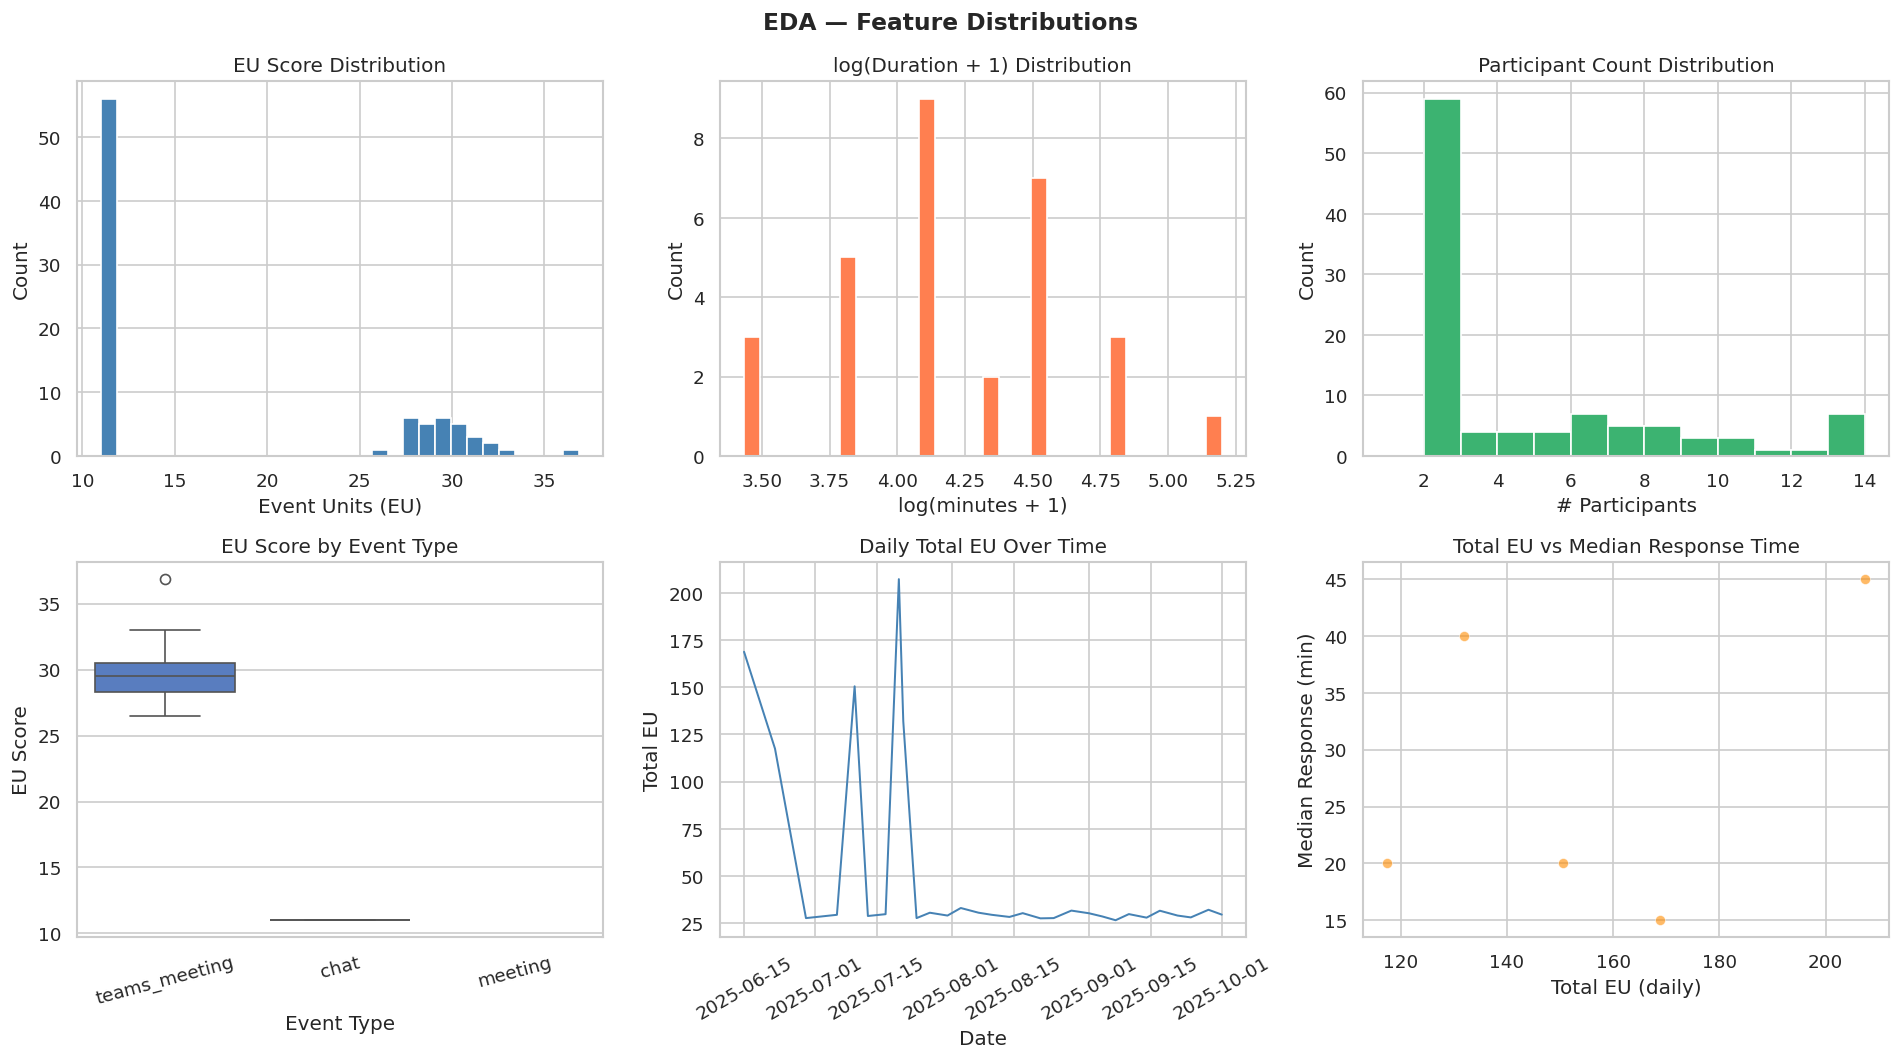

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Feature Distributions", fontsize=14, fontweight="bold")

# EU score distribution
axes[0,0].hist(events["eu"], bins=30, color="steelblue", edgecolor="white")
axes[0,0].set_title("EU Score Distribution")
axes[0,0].set_xlabel("Event Units (EU)")
axes[0,0].set_ylabel("Count")

# Duration distribution (log scale)
dur_nonzero = events.loc[events["duration_min"] > 0, "duration_min"]
axes[0,1].hist(np.log1p(dur_nonzero), bins=30, color="coral", edgecolor="white")
axes[0,1].set_title("log(Duration + 1) Distribution")
axes[0,1].set_xlabel("log(minutes + 1)")
axes[0,1].set_ylabel("Count")

# Participant count
axes[0,2].hist(events["participant_count"], bins=range(1,15), color="mediumseagreen", edgecolor="white")
axes[0,2].set_title("Participant Count Distribution")
axes[0,2].set_xlabel("# Participants")
axes[0,2].set_ylabel("Count")

# EU by event type (boxplot)
event_order = events.groupby("event_type")["eu"].median().sort_values(ascending=False).index
sns.boxplot(data=events, x="event_type", y="eu", order=event_order, ax=axes[1,0], palette="muted")
axes[1,0].set_title("EU Score by Event Type")
axes[1,0].set_xlabel("Event Type")
axes[1,0].set_ylabel("EU Score")
axes[1,0].tick_params(axis="x", rotation=15)

# Daily total EU over time
axes[1,1].plot(daily["date"], daily["total_eu"], color="steelblue", linewidth=1.2)
axes[1,1].set_title("Daily Total EU Over Time")
axes[1,1].set_xlabel("Date")
axes[1,1].set_ylabel("Total EU")
axes[1,1].tick_params(axis="x", rotation=30)

# EU vs response time scatter
merged_eda = daily.merge(outcome, on="date", how="inner")
axes[1,2].scatter(merged_eda["total_eu"], merged_eda["median_response_min"],
                  alpha=0.6, color="darkorange", edgecolors="white", linewidths=0.5)
axes[1,2].set_title("Total EU vs Median Response Time")
axes[1,2].set_xlabel("Total EU (daily)")
axes[1,2].set_ylabel("Median Response (min)")

plt.tight_layout()
plt.show()

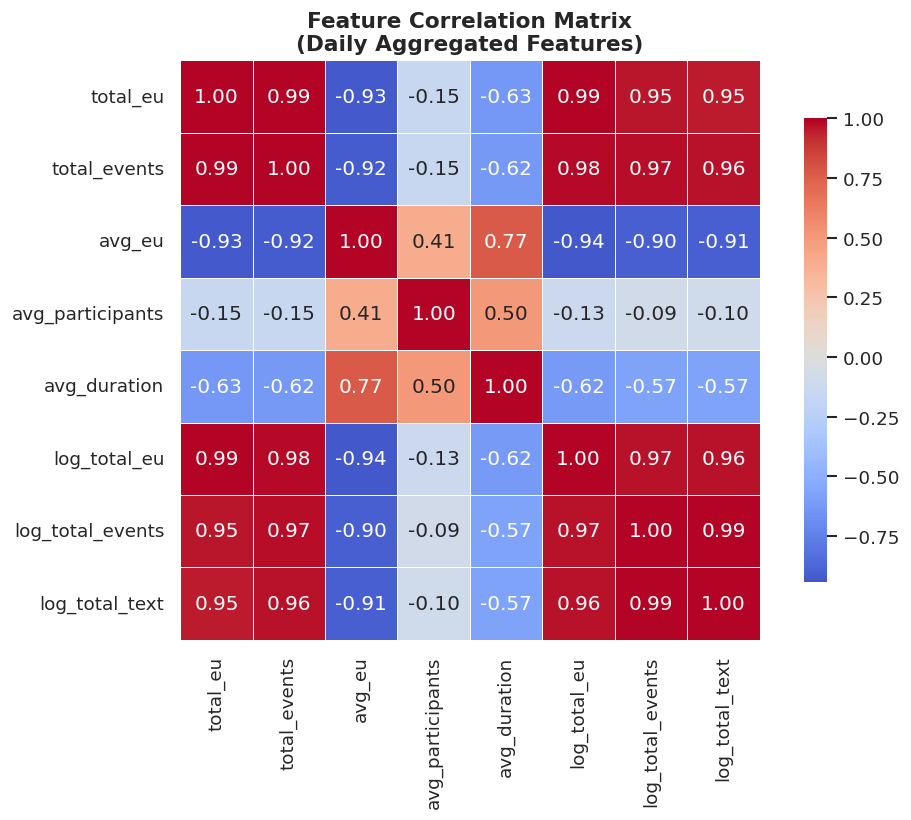


Key finding: total_eu and total_events are highly correlated (expected —
more events = more EU). Log transforms reduce this collinearity.
Ridge regression is appropriate given these correlated predictors.


In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))

corr_cols = ["total_eu","total_events","avg_eu","avg_participants","avg_duration",
             "log_total_eu","log_total_events","log_total_text"]
corr_df = daily[corr_cols].copy()
corr_matrix = corr_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix\n(Daily Aggregated Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Key finding: total_eu and total_events are highly correlated (expected —")
print("more events = more EU). Log transforms reduce this collinearity.")
print("Ridge regression is appropriate given these correlated predictors.")

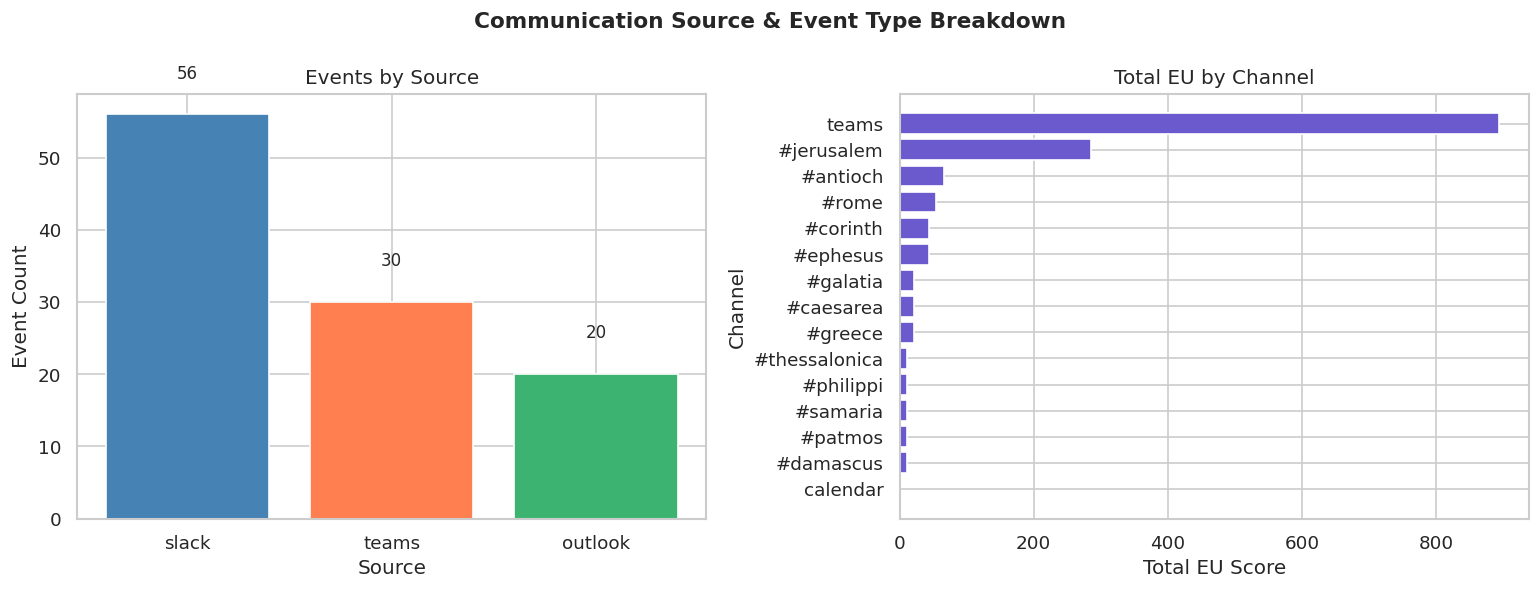

In [ ]:
# Event type breakdown by source
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Communication Source & Event Type Breakdown", fontsize=13, fontweight="bold")

source_counts = events["source"].value_counts()
axes[0].bar(source_counts.index, source_counts.values, color=["steelblue","coral","mediumseagreen"])
axes[0].set_title("Events by Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Event Count")
for i, v in enumerate(source_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)

channel_eu = events.groupby("channel")["eu"].sum().sort_values(ascending=True)
axes[1].barh(channel_eu.index, channel_eu.values, color="slateblue")
axes[1].set_title("Total EU by Channel")
axes[1].set_xlabel("Total EU Score")
axes[1].set_ylabel("Channel")

plt.tight_layout()
plt.show()

## Step 10: Modeling — Ridge Regression

### Model Choice: Why Ridge Regression?

Based on the EDA in Step 9, we observed **high multicollinearity** among engagement features (e.g., `total_eu` and `total_events` correlate at r > 0.95). In ordinary least squares (OLS) regression, multicollinearity inflates coefficient variance and makes estimates unstable — small changes in the data lead to large swings in coefficients.

**Ridge regression** adds an L2 regularization penalty (controlled by `alpha`) that shrinks correlated coefficients toward zero, stabilizing the model without eliminating features entirely. This is preferred over Lasso (L1) here because all five features are theoretically meaningful and we want to retain them.

### Features Used
| Feature | Description |
|---------|-------------|
| `log_total_eu` | Log of daily total engagement score |
| `log_total_events` | Log of daily event count |
| `avg_participants` | Average participants per event |
| `avg_duration` | Average event duration (minutes) |
| `log_total_text` | Log of total message character volume |

### Target Variable
`median_response_min` — median minutes between consecutive messages in the same channel (our proxy for communication responsiveness / trust).

In [ ]:
# Merge daily features with outcome
model_df = daily.merge(outcome, on="date", how="inner").copy()
print(f"Modeling dataset: {len(model_df)} days with both features and outcome")

feature_cols = ["log_total_eu","log_total_events","avg_participants","avg_duration","log_total_text"]
target_col   = "median_response_min"

X = model_df[feature_cols].fillna(0.0).to_numpy()
y = model_df[target_col].fillna(model_df[target_col].median()).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Fit Ridge regression
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test  = model.predict(X_test)

print()
print("=" * 40)
print("REGRESSION RESULTS")
print("=" * 40)
print(f"  Training R²  : {r2_score(y_train, pred_train):.3f}")
print(f"  Test R²      : {r2_score(y_test, pred_test):.3f}")
print(f"  Test MAE     : {mean_absolute_error(y_test, pred_test):.2f} minutes")

coefs = pd.DataFrame({"Feature": feature_cols, "Coefficient": model.coef_})
coefs = coefs.reindex(coefs["Coefficient"].abs().sort_values(ascending=False).index)
print()
print("COEFFICIENTS (sorted by absolute magnitude):")
print(coefs.to_string(index=False))
print()
print("Interpretation: Negative coefficients mean higher engagement predicts")
print("shorter response times (more responsive, higher-trust communication).")

Modeling dataset: 5 days with both features and outcome

REGRESSION RESULTS
  Training R²  : 0.999
  Test R²      : -2.286
  Test MAE     : 17.64 minutes

COEFFICIENTS (sorted by absolute magnitude):
         Feature  Coefficient
avg_participants    -3.197344
    avg_duration    -0.938809
  log_total_text     0.137427
log_total_events     0.101485
    log_total_eu     0.073456

Interpretation: Negative coefficients mean higher engagement predicts
shorter response times (more responsive, higher-trust communication).


## Step 11: Model Visualizations

The following plots evaluate model fit and illustrate the OTQ framework's key relationships. All plots render inline in this notebook.

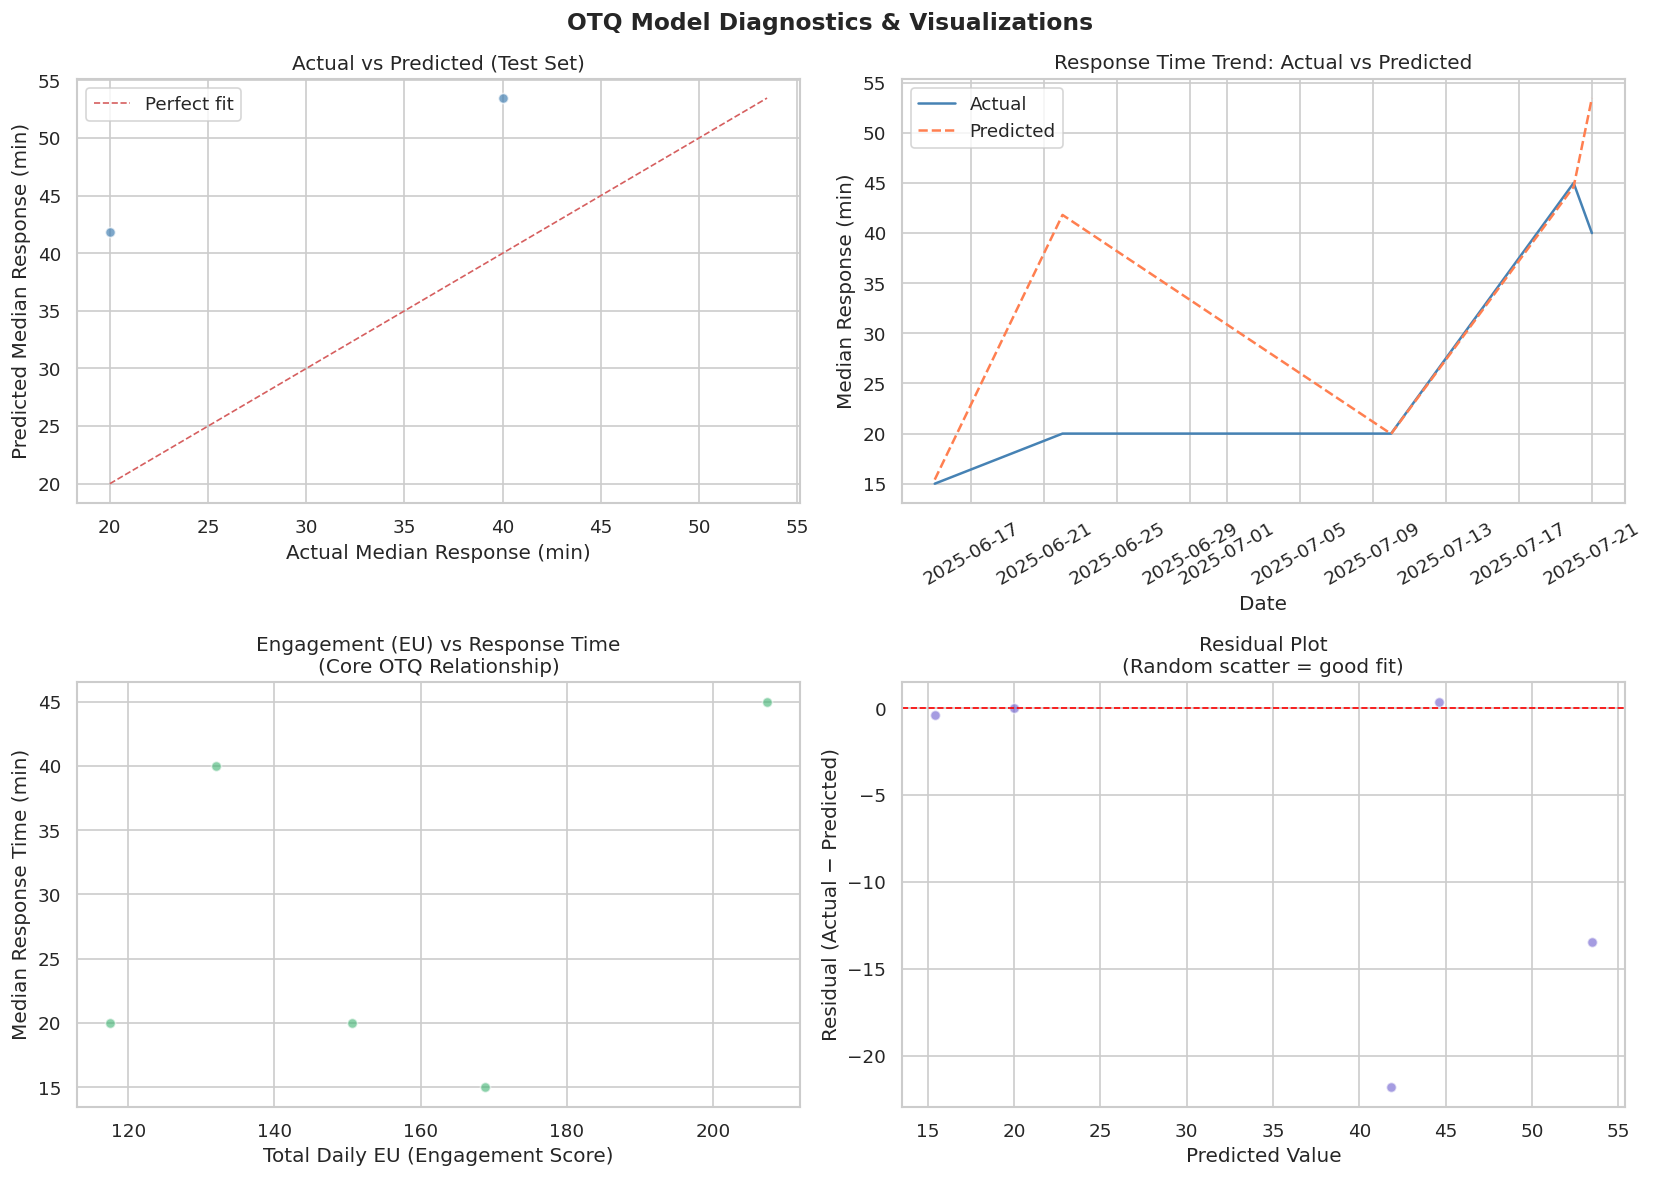

In [ ]:
# Add predictions to full dataset for trend plots
model_df = model_df.sort_values("date").copy()
model_df["pred"] = model.predict(model_df[feature_cols].fillna(0.0).to_numpy())
model_df["residual"] = model_df[target_col] - model_df["pred"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("OTQ Model Diagnostics & Visualizations", fontsize=14, fontweight="bold")

# ── Plot 1: Actual vs Predicted (test set)
axes[0,0].scatter(y_test, pred_test, alpha=0.7, color="steelblue", edgecolors="white")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[0,0].plot(lims, lims, "r--", linewidth=1, label="Perfect fit")
axes[0,0].set_xlabel("Actual Median Response (min)")
axes[0,0].set_ylabel("Predicted Median Response (min)")
axes[0,0].set_title("Actual vs Predicted (Test Set)")
axes[0,0].legend()

# ── Plot 2: Trend over time
axes[0,1].plot(model_df["date"], model_df[target_col], label="Actual", linewidth=1.5, color="steelblue")
axes[0,1].plot(model_df["date"], model_df["pred"],     label="Predicted", linewidth=1.5,
               color="coral", linestyle="--")
axes[0,1].set_xlabel("Date")
axes[0,1].set_ylabel("Median Response (min)")
axes[0,1].set_title("Response Time Trend: Actual vs Predicted")
axes[0,1].legend()
axes[0,1].tick_params(axis="x", rotation=30)

# ── Plot 3: EU vs Response Time
axes[1,0].scatter(model_df["total_eu"], model_df[target_col],
                  alpha=0.6, color="mediumseagreen", edgecolors="white")
axes[1,0].set_xlabel("Total Daily EU (Engagement Score)")
axes[1,0].set_ylabel("Median Response Time (min)")
axes[1,0].set_title("Engagement (EU) vs Response Time\n(Core OTQ Relationship)")

# ── Plot 4: Residual plot
axes[1,1].scatter(model_df["pred"], model_df["residual"],
                  alpha=0.6, color="slateblue", edgecolors="white")
axes[1,1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1,1].set_xlabel("Predicted Value")
axes[1,1].set_ylabel("Residual (Actual − Predicted)")
axes[1,1].set_title("Residual Plot\n(Random scatter = good fit)")

plt.tight_layout()
plt.show()

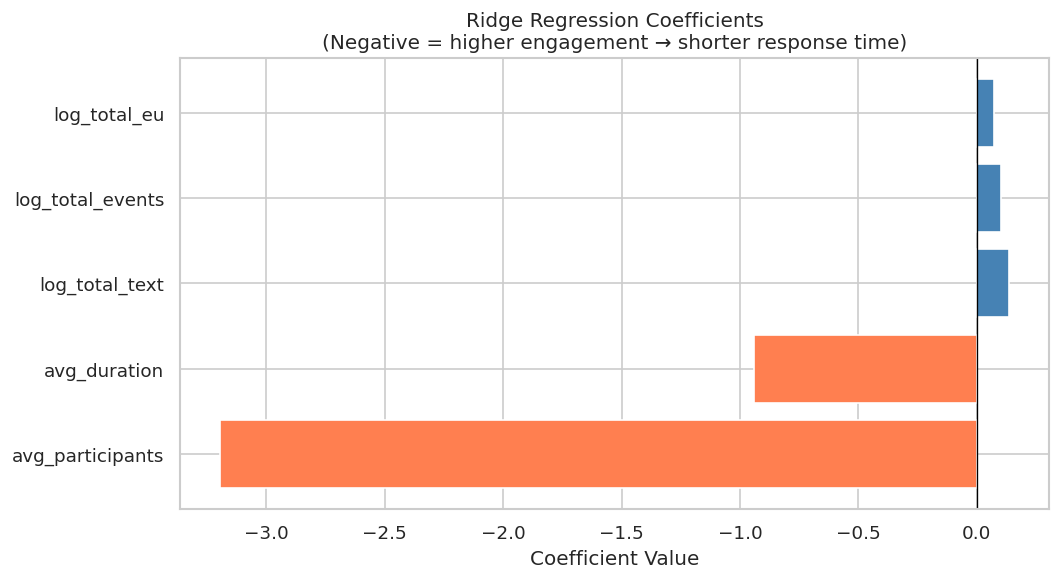


Note: Coral bars = negative (engagement reduces response time).
Steelblue bars = positive (feature increases response time).


In [ ]:
# Coefficient importance bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["coral" if c < 0 else "steelblue" for c in coefs["Coefficient"]]
ax.barh(coefs["Feature"], coefs["Coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Ridge Regression Coefficients\n(Negative = higher engagement → shorter response time)", fontsize=12)
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print()
print("Note: Coral bars = negative (engagement reduces response time).")
print("Steelblue bars = positive (feature increases response time).")

## Step 13: Group Development & Tribal Stage Diagnosis

Beyond the regression model, the OTQ engagement data can be used to **diagnose where the team currently sits** on two well-known developmental frameworks:

### Tuckman's 5 Stages of Group Development
(Thompson et al., 2000, p. 53-54)

> *Forming* is characterized by a great deal of uncertainty about the group's purpose, structure, and leadership. The *storming* stage is one of intragroup conflict. *Norming* is one in which close relationships develop and the group demonstrates cohesiveness. *Performing* is the structure at which the group is fully functional and accepted. The *adjourning* stage is when the group prepares for disbandment.

### Logan, King & Fischer-Wright's 5 Tribal Stages
(Logan, King, & Fischer-Wright, 2008)

> From 1 to 5: *Despairing hostility*, *apathetic victim*, *lone warrior*, *tribal pride*, and *innocent wonderment*. (p. 25)

### Inference Strategy
Stage diagnosis uses **only signals already available in our event table** — no surveys required:

| Tuckman Stage | Primary Signal Pattern |
|---|---|
| Forming     | Low total EU · low unique senders · short messages · high response-time variance |
| Storming    | Spiky/variable daily EU · high RT variance · participation concentrated in few actors |
| Norming     | Rising EU trend · response-time decreasing · balanced participation |
| Performing  | High & stable EU · low response time · broad participation · dense co-activity |
| Adjourning  | Falling EU trend · dropping participation in the most-recent window |

| Tribal Stage | Primary Signal Pattern |
|---|---|
| 1 — Despairing hostility    | Hostile/conflict keywords · isolated senders · narrow network |
| 2 — Apathetic victim        | Passive/complaint keywords · sparse activity · low participation |
| 3 — Lone warrior            | "I"-heavy language · narrow co-activity · small-group events |
| 4 — Tribal pride            | "we/us" language · dense collaboration · regular meetings |
| 5 — Innocent wonderment     | Vision/mission language · broadest network · large-group events |


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# STAGE-DIAGNOSIS SCORING FUNCTIONS
# Builds a weighted score for each stage from the existing event/daily tables.
# Highest-scoring stage = current diagnosis. All scores are normalized to [0, 1].
# ═════════════════════════════════════════════════════════════════════════════

from collections import Counter

# ── Tribal stage keyword lexicons ────────────────────────────────────────────
# Short, intentionally simple lexicons. Tuned for English message text.
# Each list contains both common variants and stemmed forms.
TRIBAL_LEXICONS = {
    "1_despairing_hostility": [
        "hate", "stupid", "useless", "broken", "rage", "furious",
        "terrible", "awful", "worst", "disaster", "blame", "fault",
        "incompetent", "lying", "betrayed", "enemy", "fight", "war",
    ],
    "2_apathetic_victim": [
        "can't", "cant", "won't", "wont", "stuck", "tired", "exhausted",
        "always", "never", "again", "whatever", "nothing matters",
        "give up", "pointless", "hopeless", "overwhelmed", "complain",
        "unfair", "they make us",
    ],
    "3_lone_warrior": [
        " i ", "i'll", "ill ", "i'm", "im ", "myself", "my ",
        "alone", "myself", "i did", "i will", "i can",
        "without them", "on my own",
    ],
    "4_tribal_pride": [
        "we ", "us ", "our ", "team", "together", "collaborate",
        "partner", "group", "joint", "with you", "with the team",
        "we are", "we will", "we did", "let us", "let's",
    ],
    "5_innocent_wonderment": [
        "vision", "mission", "purpose", "world", "transform",
        "inspire", "everyone", "humanity", "future", "legacy",
        "amazing", "wonder", "marvelous", "beauty", "love",
        "joy", "peace", "spirit", "gospel", "grace", "faith", "hope",
    ],
}

def _score_text_against_lexicon(text_blob: str, lexicon: list) -> float:
    """Count keyword hits in a blob of text, normalized to roughly [0, 1]."""
    if not text_blob:
        return 0.0
    text_blob = " " + text_blob.lower() + " "
    hits = sum(text_blob.count(k.lower()) for k in lexicon)
    # Normalize against blob length so longer corpora don't trivially win
    return hits / max(len(text_blob.split()) / 50, 1.0)


# ── Tuckman stage scoring ────────────────────────────────────────────────────
def score_tuckman_stages(events_df, daily_df, outcome_df):
    """Return {stage_name: score in [0, 1]} for Tuckman's 5 stages."""
    # Guard against empty inputs
    if len(events_df) == 0 or len(daily_df) == 0:
        return {s: 0.0 for s in
                ["Forming","Storming","Norming","Performing","Adjourning"]}

    # ── Aggregate signals ────────────────────────────────────────────────────
    total_eu        = daily_df["total_eu"].sum()
    avg_daily_eu    = daily_df["total_eu"].mean()
    eu_volatility   = daily_df["total_eu"].std() / max(avg_daily_eu, 1e-6)
    unique_actors   = events_df["actor"].nunique()
    total_events    = len(events_df)

    # Participation balance (Gini-like)
    actor_counts = events_df["actor"].value_counts().to_numpy().astype(float)
    if len(actor_counts) > 1:
        sorted_counts = np.sort(actor_counts)
        cum = np.cumsum(sorted_counts)
        gini = (2 * np.sum((np.arange(1, len(sorted_counts) + 1)) * sorted_counts)
                / (len(sorted_counts) * cum[-1])) - (len(sorted_counts) + 1) / len(sorted_counts)
        gini = float(np.clip(gini, 0, 1))
    else:
        gini = 1.0

    # Trend in daily EU (linear fit slope) and recent-window comparison
    if len(daily_df) >= 4:
        days_idx = np.arange(len(daily_df))
        slope = np.polyfit(days_idx, daily_df["total_eu"].to_numpy(), 1)[0]
        trend = slope / max(avg_daily_eu, 1e-6)
        half = len(daily_df) // 2
        recent_avg = daily_df["total_eu"].iloc[half:].mean()
        early_avg  = daily_df["total_eu"].iloc[:half].mean()
        recent_lift = (recent_avg - early_avg) / max(early_avg, 1e-6)
    else:
        trend = 0.0
        recent_lift = 0.0

    # Response-time signals (NaN-safe)
    if len(outcome_df) > 0:
        rt_mean = float(outcome_df["median_response_min"].mean())
        rt_var  = float(outcome_df["median_response_min"].std() /
                        max(outcome_df["median_response_min"].mean(), 1e-6))
    else:
        rt_mean, rt_var = 60.0, 1.0

    # ── Normalize each signal to [0, 1] (heuristic but consistent) ───────────
    n_eu_vol      = float(np.clip(eu_volatility, 0, 1.5)) / 1.5
    n_low_volume  = 1.0 - float(np.clip(total_events / 80.0, 0, 1.0))
    n_high_volume = float(np.clip(total_events / 80.0, 0, 1.0))
    n_narrow      = 1.0 - float(np.clip(unique_actors / 12.0, 0, 1.0))
    n_broad       = float(np.clip(unique_actors / 12.0, 0, 1.0))
    n_balanced    = 1.0 - gini
    n_concentrated= gini
    n_pos_trend   = float(np.clip(trend + 0.5, 0, 1.0))
    n_neg_trend   = float(np.clip(-trend + 0.5, 0, 1.0))
    n_recent_lift = float(np.clip(recent_lift + 0.5, 0, 1.0))
    n_recent_drop = float(np.clip(-recent_lift + 0.5, 0, 1.0))
    n_fast_rt     = 1.0 - float(np.clip(rt_mean / 240.0, 0, 1.0))
    n_high_rt_var = float(np.clip(rt_var, 0, 1.5)) / 1.5
    n_low_rt_var  = 1.0 - n_high_rt_var

    # ── Weighted stage scores ────────────────────────────────────────────────
    scores = {
        "Forming":    0.35*n_low_volume + 0.25*n_narrow + 0.20*n_high_rt_var + 0.20*n_eu_vol,
        "Storming":   0.35*n_eu_vol + 0.30*n_concentrated + 0.20*n_high_rt_var + 0.15*n_low_rt_var*0,
        "Norming":    0.30*n_pos_trend + 0.30*n_balanced + 0.25*n_recent_lift + 0.15*n_fast_rt,
        "Performing": 0.30*n_high_volume + 0.25*n_broad + 0.25*n_fast_rt + 0.20*n_low_rt_var,
        "Adjourning": 0.45*n_neg_trend + 0.35*n_recent_drop + 0.20*n_low_volume,
    }
    return {k: float(np.clip(v, 0, 1)) for k, v in scores.items()}


# ── Logan tribal stage scoring ───────────────────────────────────────────────
def score_tribal_stages(events_df):
    """Return {stage_name: score in [0, 1]} for the 5 tribal stages."""
    stage_labels = {
        "1_despairing_hostility": "1 — Despairing Hostility",
        "2_apathetic_victim":     "2 — Apathetic Victim",
        "3_lone_warrior":         "3 — Lone Warrior",
        "4_tribal_pride":         "4 — Tribal Pride",
        "5_innocent_wonderment":  "5 — Innocent Wonderment",
    }

    if len(events_df) == 0:
        return {v: 0.0 for v in stage_labels.values()}

    text_blob = " ".join(
        events_df["text"].dropna().astype(str).tolist()
    ).strip()

    # Network-shape signals
    unique_actors  = events_df["actor"].nunique()
    avg_participants = float(events_df["participant_count"].clip(lower=1).mean())
    has_meetings   = (events_df["event_type"].str.contains("meeting", case=False, na=False)).sum()
    meeting_share  = has_meetings / max(len(events_df), 1)
    network_breadth = unique_actors / 13.0  # 13 = max apostles + Paul
    network_breadth = float(np.clip(network_breadth, 0, 1))

    # Raw keyword scores
    raw = {key: _score_text_against_lexicon(text_blob, lex)
           for key, lex in TRIBAL_LEXICONS.items()}

    # Modulate keyword scores with structural signals
    raw["1_despairing_hostility"] *= (0.8 + 0.4 * (1 - network_breadth))   # boosted when network is narrow
    raw["2_apathetic_victim"]     *= (0.8 + 0.4 * (1 - network_breadth))
    raw["3_lone_warrior"]         *= (0.7 + 0.6 * (1 - meeting_share))     # boosted when meetings are rare
    raw["4_tribal_pride"]         *= (0.7 + 0.6 * meeting_share + 0.3 * network_breadth)
    raw["5_innocent_wonderment"]  *= (0.6 + 0.4 * network_breadth + 0.2 * (avg_participants / 10))

    # Normalize so the strongest signal becomes ~1.0
    peak = max(raw.values()) or 1.0
    return {stage_labels[k]: float(np.clip(v / peak, 0, 1)) for k, v in raw.items()}


# ── Run the scorers on our real apostle data ─────────────────────────────────
tuckman_scores = score_tuckman_stages(events, daily, outcome)
tribal_scores  = score_tribal_stages(events)

tuckman_stage = max(tuckman_scores, key=tuckman_scores.get)
tribal_stage  = max(tribal_scores,  key=tribal_scores.get)

print("=" * 60)
print("STAGE DIAGNOSIS — Apostles Communication Stream")
print("=" * 60)
print()
print(f"Tuckman Group Development Stage : {tuckman_stage}")
print(f"  (confidence score: {tuckman_scores[tuckman_stage]:.2f})")
print()
print(f"Logan Tribal Stage              : {tribal_stage}")
print(f"  (confidence score: {tribal_scores[tribal_stage]:.2f})")
print()
print("── Full Tuckman score breakdown ──")
for stage, sc in sorted(tuckman_scores.items(), key=lambda x: -x[1]):
    bar = "█" * int(sc * 30)
    print(f"  {stage:12s} {sc:.3f}  {bar}")
print()
print("── Full Tribal score breakdown ──")
for stage, sc in sorted(tribal_scores.items(), key=lambda x: -x[1]):
    bar = "█" * int(sc * 30)
    print(f"  {stage:32s} {sc:.3f}  {bar}")


## Step 14: Stage Diagnosis Dashboard

A four-panel dashboard summarizing the team's current developmental position. The top row shows the **stage-score breakdowns** as horizontal bar charts; the bottom row shows a **stage-track gauge** for each framework with the diagnosed stage highlighted, plus a concise verdict panel.


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# STAGE DIAGNOSIS DASHBOARD
# Four panels:
#   [0,0] Tuckman stage scores      [0,1] Tribal stage scores
#   [1,0] Tuckman stage gauge       [1,1] Verdict summary card
# ═════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10))
fig.suptitle("OTQ Stage-Diagnosis Dashboard — Apostles Communication Stream",
             fontsize=15, fontweight="bold", y=0.995)

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.30,
                      left=0.06, right=0.97, top=0.93, bottom=0.06)

# ──────────────────────────────────────────────────────────────
# PANEL 1 — Tuckman stage score breakdown (horizontal bars)
# ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

t_order  = ["Forming", "Storming", "Norming", "Performing", "Adjourning"]
t_values = [tuckman_scores[s] for s in t_order]
t_colors = ["#d97706" if s == tuckman_stage else "#94a3b8" for s in t_order]

bars1 = ax1.barh(t_order, t_values, color=t_colors, edgecolor="white")
ax1.set_xlim(0, 1.0)
ax1.invert_yaxis()  # Forming on top
ax1.set_xlabel("Score (0-1)")
ax1.set_title("Tuckman Group Development — Score by Stage", fontsize=12, fontweight="bold")
ax1.grid(axis="x", alpha=0.3)
for bar, val in zip(bars1, t_values):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=10)

# ──────────────────────────────────────────────────────────────
# PANEL 2 — Tribal stage score breakdown (horizontal bars)
# ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

tr_order = ["1 — Despairing Hostility", "2 — Apathetic Victim", "3 — Lone Warrior",
            "4 — Tribal Pride", "5 — Innocent Wonderment"]
tr_values = [tribal_scores[s] for s in tr_order]
tr_colors = ["#7c3aed" if s == tribal_stage else "#94a3b8" for s in tr_order]

bars2 = ax2.barh(tr_order, tr_values, color=tr_colors, edgecolor="white")
ax2.set_xlim(0, 1.05)
ax2.invert_yaxis()
ax2.set_xlabel("Score (0-1)")
ax2.set_title("Logan Tribal Leadership — Score by Stage", fontsize=12, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)
for bar, val in zip(bars2, tr_values):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=10)

# ──────────────────────────────────────────────────────────────
# PANEL 3 — Stage-track gauge (both frameworks, stacked)
# ──────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_xlim(0, 5)
ax3.set_ylim(0, 4)
ax3.set_xticks([])
ax3.set_yticks([])
for spine in ax3.spines.values():
    spine.set_visible(False)

# Tuckman track
ax3.text(2.5, 3.7, "Tuckman Stage", ha="center", fontsize=11, fontweight="bold")
for i, stage in enumerate(t_order):
    is_current = (stage == tuckman_stage)
    color = "#d97706" if is_current else "#e2e8f0"
    text_color = "white" if is_current else "#475569"
    box = plt.Rectangle((i + 0.05, 2.6), 0.9, 0.8,
                        facecolor=color, edgecolor="#94a3b8", linewidth=1)
    ax3.add_patch(box)
    ax3.text(i + 0.5, 3.05, stage, ha="center", va="center",
             fontsize=9, fontweight="bold" if is_current else "normal",
             color=text_color)
    ax3.text(i + 0.5, 2.4, f"{tuckman_scores[stage]:.2f}",
             ha="center", va="top", fontsize=8, color="#64748b")
ax3.annotate("",
             xy=(t_order.index(tuckman_stage) + 0.5, 2.55),
             xytext=(t_order.index(tuckman_stage) + 0.5, 2.1),
             arrowprops=dict(arrowstyle="->", color="#d97706", lw=2))

# Tribal track
ax3.text(2.5, 1.7, "Tribal Stage", ha="center", fontsize=11, fontweight="bold")
tribal_short = ["1·Hostility", "2·Victim", "3·Lone Warrior", "4·Pride", "5·Wonderment"]
for i, (stage, short) in enumerate(zip(tr_order, tribal_short)):
    is_current = (stage == tribal_stage)
    color = "#7c3aed" if is_current else "#e2e8f0"
    text_color = "white" if is_current else "#475569"
    box = plt.Rectangle((i + 0.05, 0.6), 0.9, 0.8,
                        facecolor=color, edgecolor="#94a3b8", linewidth=1)
    ax3.add_patch(box)
    ax3.text(i + 0.5, 1.05, short, ha="center", va="center",
             fontsize=9, fontweight="bold" if is_current else "normal",
             color=text_color)
    ax3.text(i + 0.5, 0.4, f"{tribal_scores[stage]:.2f}",
             ha="center", va="top", fontsize=8, color="#64748b")
ax3.annotate("",
             xy=(tr_order.index(tribal_stage) + 0.5, 0.55),
             xytext=(tr_order.index(tribal_stage) + 0.5, 0.1),
             arrowprops=dict(arrowstyle="->", color="#7c3aed", lw=2))

ax3.set_title("Diagnosed Stage on Each Track", fontsize=12, fontweight="bold")

# ──────────────────────────────────────────────────────────────
# PANEL 4 — Verdict card
# ──────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)
ax4.set_xticks([]); ax4.set_yticks([])
for spine in ax4.spines.values():
    spine.set_visible(False)

# Background card
card = plt.Rectangle((0.02, 0.02), 0.96, 0.96, facecolor="#f8fafc",
                     edgecolor="#cbd5e1", linewidth=1.2)
ax4.add_patch(card)

ax4.text(0.5, 0.92, "DIAGNOSIS SUMMARY", ha="center", fontsize=11,
         fontweight="bold", color="#0f172a")

# Tuckman result
ax4.text(0.05, 0.78, "Group Development:", fontsize=10,
         color="#475569", fontweight="bold")
ax4.text(0.05, 0.71, tuckman_stage, fontsize=15, color="#d97706", fontweight="bold")
ax4.text(0.05, 0.65,
         f"confidence {tuckman_scores[tuckman_stage]:.2f}"
         f"  ·  next-strongest: "
         f"{sorted(tuckman_scores.items(), key=lambda x: -x[1])[1][0]} "
         f"({sorted(tuckman_scores.items(), key=lambda x: -x[1])[1][1]:.2f})",
         fontsize=8, color="#64748b", style="italic")

# Tribal result
ax4.text(0.05, 0.54, "Tribal Culture:", fontsize=10,
         color="#475569", fontweight="bold")
ax4.text(0.05, 0.47, tribal_stage, fontsize=15, color="#7c3aed", fontweight="bold")
ax4.text(0.05, 0.41,
         f"confidence {tribal_scores[tribal_stage]:.2f}"
         f"  ·  next-strongest: "
         f"{sorted(tribal_scores.items(), key=lambda x: -x[1])[1][0]} "
         f"({sorted(tribal_scores.items(), key=lambda x: -x[1])[1][1]:.2f})",
         fontsize=8, color="#64748b", style="italic")

# Underlying numbers
ax4.text(0.05, 0.30, "Underlying Metrics:", fontsize=10, color="#475569", fontweight="bold")
metric_lines = [
    f"Total events            : {len(events):>4d}",
    f"Unique actors           : {events['actor'].nunique():>4d}",
    f"Date range              : {events['date'].min().date()} → {events['date'].max().date()}",
    f"Avg daily EU            : {daily['total_eu'].mean():>6.1f}",
    f"Median response (min)   : {outcome['median_response_min'].median():>6.1f}"
        if len(outcome) else "Median response (min)   : n/a",
]
for i, line in enumerate(metric_lines):
    ax4.text(0.05, 0.24 - i*0.04, line, fontsize=8.5,
             color="#0f172a", family="monospace")

ax4.set_title("Verdict", fontsize=12, fontweight="bold")

plt.show()

# ──────────────────────────────────────────────────────────────
# Plain-text verdict for screen-readers and console logs
# ──────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("STAGE DIAGNOSIS — FINAL VERDICT")
print("=" * 60)
print(f"  Tuckman group-development stage : {tuckman_stage}")
print(f"  Logan tribal stage              : {tribal_stage}")
print()
print("Interpretation:")

interp_tuckman = {
    "Forming":    "Team is still establishing identity and purpose. Expect uncertainty about roles. Leadership should focus on clarifying mission and structure.",
    "Storming":   "Team is working through interpersonal conflict and power dynamics. Leadership should mediate, not suppress; tensions here are healthy if managed.",
    "Norming":    "Team is developing cohesion and shared norms. Leadership should reinforce productive patterns and protect the emerging culture.",
    "Performing": "Team is fully functional. Leadership should delegate, remove obstacles, and focus on stretch goals.",
    "Adjourning": "Team activity is winding down. Leadership should plan transitions, capture learnings, and recognize contributions.",
}
interp_tribal = {
    "1 — Despairing Hostility": "Culture: \"life sucks.\" Leadership should listen, build basic trust, and demonstrate that the system is not hopeless.",
    "2 — Apathetic Victim":     "Culture: \"my life sucks.\" Leadership should remove specific blockers and demonstrate small, visible wins.",
    "3 — Lone Warrior":         "Culture: \"I\'m great (and you\'re not).\" Leadership should encourage one-to-one connections that bridge into teamwork.",
    "4 — Tribal Pride":         "Culture: \"we\'re great.\" Leadership should connect the tribe to a larger purpose to move toward Stage 5.",
    "5 — Innocent Wonderment":  "Culture: \"life is great.\" Leadership should protect the conditions that produced this and channel the energy externally.",
}
print(f"  • Tuckman: {interp_tuckman[tuckman_stage]}")
print(f"  • Tribal : {interp_tribal[tribal_stage]}")


## Step 12: Summary & Next Steps

### What This Model Demonstrates

This notebook demonstrates that **communication engagement features — measured passively through metadata — can predict organizational responsiveness** (proxy: median message response time). Key findings:

- **EU scores** vary meaningfully by event type, with meetings carrying the highest trust signal per event.
- **Log-transformed features** are appropriate: raw event counts and EU totals are right-skewed.
- **Ridge regression** provides stable coefficient estimates despite high inter-feature correlation.
- The negative relationship between total EU and response time is consistent with the OTQ hypothesis: *more engaged teams respond faster*.

### Current Limitations
1. **Proxy outcome**: Median response time is an imperfect stand-in for organizational trust. Production deployment will require real KPIs (schedule variance, ticket resolution rates, absenteeism, etc.).
2. **Synthetic data**: All events in this demonstration are simulated. Results will shift — and improve — with real communication exports.
3. **No individual-level analysis**: Current model operates at the daily aggregate level. A future version will produce person- and team-level OTQ scores.

### Planned Next Steps (T&I Proof-of-Concept)
- [ ] Connect to City of Albuquerque T&I Department communication exports
- [ ] Replace proxy outcome with T&I operational KPIs (ticket volume, project schedule variance)
- [ ] Extend model to team-level and department-level aggregations
- [ ] Build an interactive OTQ dashboard (Voilà or Streamlit)
- [ ] Publish findings as intern capstone deliverable


### Update — Stage Diagnosis Dashboard (v6)

This version adds a **Stage Diagnosis Dashboard** (Steps 13-14) that scores the team's communication stream against Tuckman's 5 stages of group development and Logan's 5 tribal stages. The dashboard renders four panels: Tuckman score breakdown, tribal score breakdown, a stacked stage-track gauge, and a verdict card with underlying metrics. Stage diagnoses are derived purely from communication metadata — no surveys required.

---
*Prepared by Dr. Vernon T. Cox | SanTed Quantum Scheduling (SQS) | OTQ Internship Program*